# 📊 K-Means e PCA com Iris
Notebook completo com resolução e gráficos.

## 🔧 1. Setup e carregamento

In [2]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 📊 2. Exploração dos dados

In [3]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
X.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [5]:
from sklearn import cluster, datasets
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target
k_means = cluster.KMeans(n_clusters=3)
k_means.fit(X_iris)
print(k_means.labels_[::10])
print(y_iris[::10])

[0 0 0 0 0 1 1 1 1 1 2 2 2 2 2]
[0 0 0 0 0 1 1 1 1 1 2 2 2 2 2]


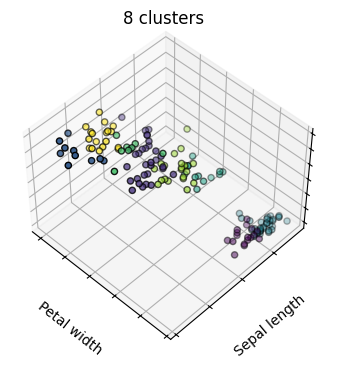

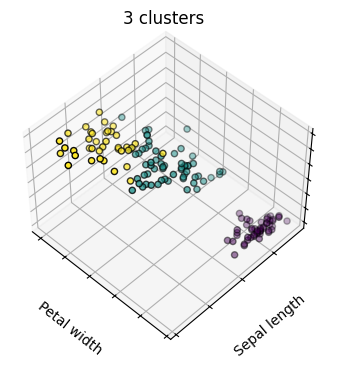

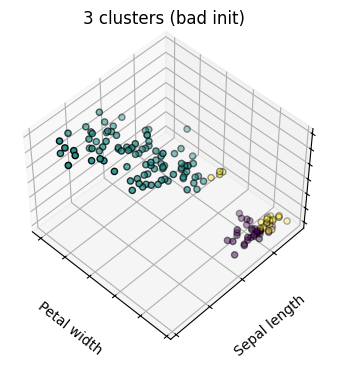

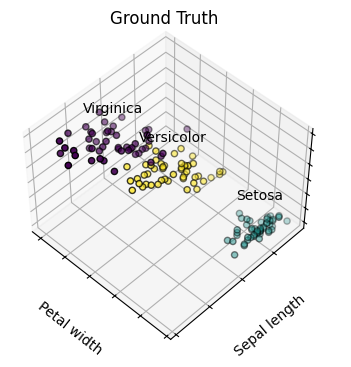

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import datasets

# Reprodutibilidade
np.random.seed(5)

# Dataset Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Modelos
estimators = [
    ('k_means_iris_8', KMeans(n_clusters=8, random_state=5)),
    ('k_means_iris_3', KMeans(n_clusters=3, random_state=5)),
    ('k_means_bad_init', KMeans(n_clusters=3, n_init=1, init='random', random_state=5))
]

titles = ['8 clusters', '3 clusters', '3 clusters (bad init)']

# Plot dos clusters
for i, (name, est) in enumerate(estimators):
    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(projection='3d')
    ax.view_init(elev=48, azim=134)

    est.fit(X)
    labels = est.labels_

    ax.scatter(
        X[:, 3], X[:, 0], X[:, 2],
        c=labels.astype(float),
        edgecolor='k'
    )

    ax.set_xlabel('Petal width')
    ax.set_ylabel('Sepal length')
    ax.set_zlabel('Petal length')
    ax.set_title(titles[i])

    # Remove números dos eixos (opcional)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

# Ground truth (valores reais)
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(projection='3d')
ax.view_init(elev=48, azim=134)

# Nomes das espécies
labels_names = ['Setosa', 'Versicolor', 'Virginica']

for label, name in enumerate(labels_names):
    ax.text(
        X[y == label, 3].mean(),
        X[y == label, 0].mean(),
        X[y == label, 2].mean() + 2,
        name,
        horizontalalignment='center'
    )

# Ajuste das cores
y_plot = np.choose(y, [1, 2, 0]).astype(float)

ax.scatter(
    X[:, 3], X[:, 0], X[:, 2],
    c=y_plot,
    edgecolor='k'
)

ax.set_xlabel('Petal width')
ax.set_ylabel('Sepal length')
ax.set_zlabel('Petal length')
ax.set_title('Ground Truth')

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

plt.show()


## 📈 3. Visualização inicial

In [7]:
plt.scatter(X.iloc[:, 2], X.iloc[:, 3], c=y)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Distribuição real das classes")
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

## 🤖 4. K-Means (K=3)

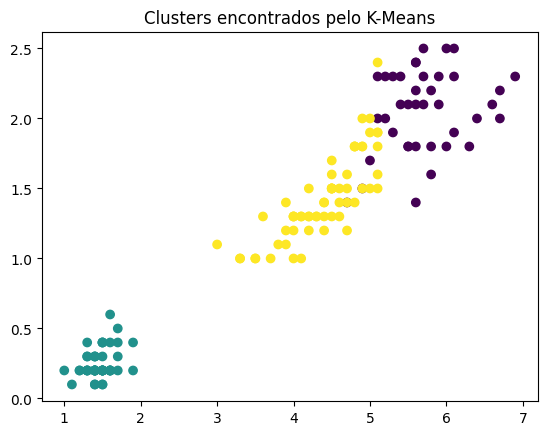

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

X['cluster'] = labels

plt.scatter(X.iloc[:, 2], X.iloc[:, 3], c=labels)
plt.title("Clusters encontrados pelo K-Means")
plt.show()

## 📉 5. Método do cotovelo

O método do cotovelo é uma técnica usada para escolher o melhor número de clusters (K) no algoritmo K-Means.

💡 Ideia principal

Quando você aumenta o número de clusters, o modelo tende a melhorar (ou seja, os grupos ficam mais “bem definidos”).
Mas essa melhora não é infinita — chega um ponto em que adicionar mais clusters traz pouco ganho.

👉 O “cotovelo” é exatamente esse ponto de equilíbrio.

📉 O que é medido?

O método usa a inércia (inertia), que representa:

A soma das distâncias dos pontos até o centróide do seu cluster
Quanto menor, melhor
📊 Como funciona na prática
Você roda o K-Means para vários valores de K (ex: 1 até 10)
Para cada K, calcula a inércia
Plota um gráfico:
Eixo X → número de clusters (K)
Eixo Y → inércia
📈 Interpretação do gráfico


👉 O “cotovelo” é o ponto onde a curva para de cair rapidamente e começa a ficar mais suave.

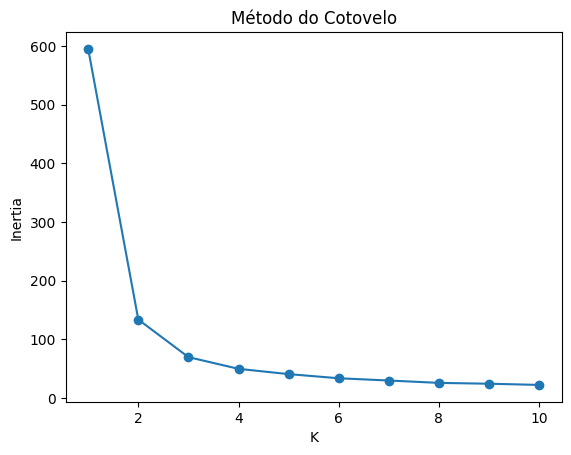

In [ ]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X.iloc[:, :-1])
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo")
plt.show()

## 📏 6. Silhouette Score

O Silhouette Score é uma métrica usada para avaliar quão bem os dados foram agrupados em um algoritmo de clustering (como K-Means). Ele ajuda a escolher o melhor número de clusters de forma mais objetiva que o método do cotovelo.

💡 Ideia principal

Para cada ponto, o Silhouette mede duas coisas:

 - $a(i) →$ quão perto o ponto está dos pontos do mesmo cluster
 - $b(i) →$ quão perto ele está do cluster vizinho mais próximo

👉 Com isso, ele calcula:

$s(i)= \frac{b(i)−a(i)}{max(a(i),b(i))}$

📊 Interpretação do valor

O score varia de -1 até 1:

 - Próximo de 1 → ponto bem agrupado ✅
 - Próximo de 0 → ponto na fronteira ⚠️
 - Próximo de -1 → provavelmente no cluster errado ❌
   
🧠 Intuição simples
- Se o ponto está mais próximo do seu grupo do que de outros → bom clustering
- Se está muito perto de outro grupo → clusters mal definidos
  
📈 Como usar na prática:
1. Teste vários valores de K (ex: 2 até 10)
2.  Para cada K:
        - Rode o K-Means
        - Calcule o Silhouette Score médio
3. Escolha o K com maior score

In [ ]:
# Compute silhouette scores for Iris dataset and determine best K
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = load_iris()
X = data.data

# Standardize (recommended)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ks = list(range(2, 11))
scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

best_k = ks[scores.index(max(scores))]
best_score = max(scores)

best_k, best_score

(2, 0.5817500491982808)

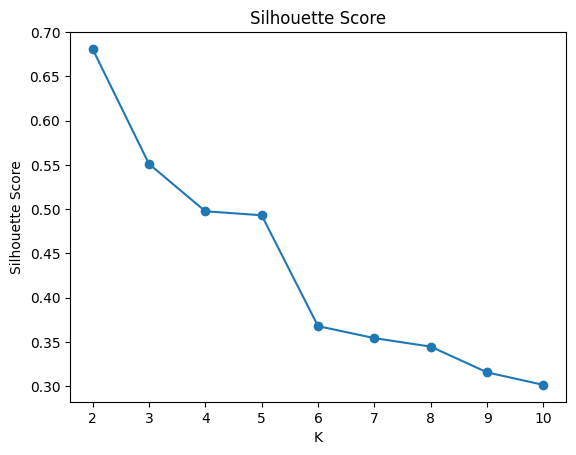

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)   # <-- aqui corrigido
    score = silhouette_score(X, labels)
    scores.append(score)

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

## ⚙️ 7. Padronização

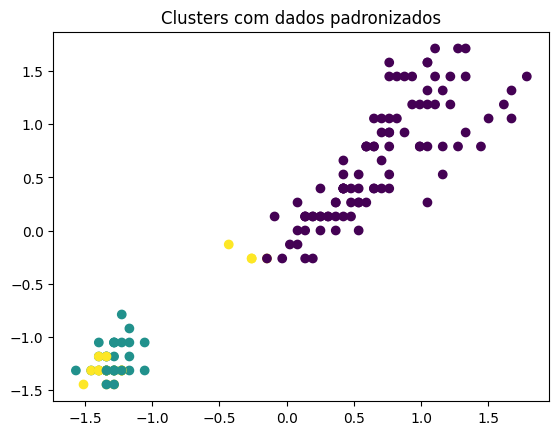

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # <-- corrigido

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 2], X_scaled[:, 3], c=labels_scaled)
plt.title("Clusters com dados padronizados")
plt.show()

## 🔽 8. PCA

## Estudo de Caso Avaliação de Crimes

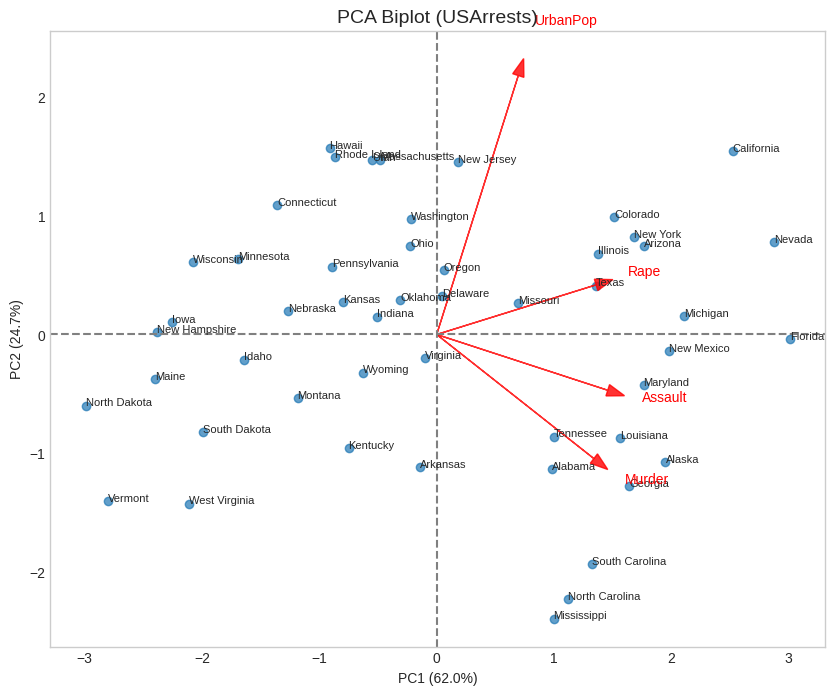

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# CONFIGURAÇÃO
# =========================
plt.style.use('seaborn-v0_8-whitegrid')

# =========================
# DADOS
# =========================
df = pd.read_csv('USArrests.csv', index_col=0)

# Padronização (ESSENCIAL para PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# =========================
# PCA
# =========================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variância explicada
explained_var = pca.explained_variance_ratio_

# DataFrame com PCs
df_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(len(df.columns))],
    index=df.index
)

# Loadings (pesos das variáveis)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(df.columns))],
    index=df.columns
)

# =========================
# BIPLOT
# =========================
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter dos estados
ax.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.7)

# Labels dos pontos
for i in df_pca.index:
    ax.text(df_pca.loc[i, 'PC1'], df_pca.loc[i, 'PC2'], i, fontsize=8)

# Eixos com variância explicada
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
ax.set_title('PCA Biplot (USArrests)', fontsize=14)

# Linhas de referência
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(0, color='grey', linestyle='--')

# =========================
# VETORES (LOADINGS)
# =========================
# Escala dos vetores
scale_factor = 2.5

for var in loadings.index:
    ax.arrow(
        0, 0,
        loadings.loc[var, 'PC1'] * scale_factor,
        loadings.loc[var, 'PC2'] * scale_factor,
        color='red',
        alpha=0.8,
        head_width=0.1
    )

    ax.text(
        loadings.loc[var, 'PC1'] * scale_factor * 1.2,
        loadings.loc[var, 'PC2'] * scale_factor * 1.2,
        var,
        color='red',
        fontsize=10
    )

plt.grid()
plt.show()

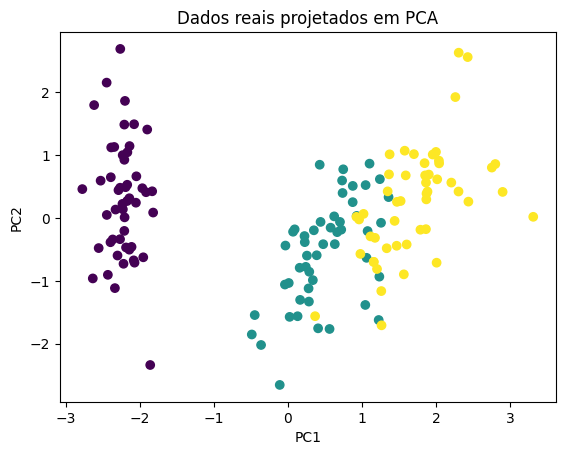

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("Dados reais projetados em PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 📊 9. Variância explicada

In [ ]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

## 🤖 10. K-Means após PCA

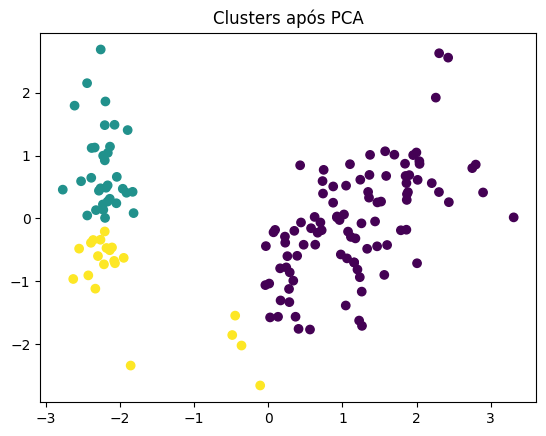

In [ ]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca)
plt.title("Clusters após PCA")
plt.show()

## 🧠 Conclusões
- K ≈ 3
- PCA mantém ~90% da variância
- PCA melhora visualização e clustering